In [1]:
import pandas as pd
df = pd.read_csv("/kaggle/input/augmented-dataset/dataset_augmented.csv")
df.head()

,text,topic
0,nhan_nhản shophouse từng là gà đẻ trứng vàng b...,Bất động sản
1,điều bất_ngờ bên trong biệt_thự hoành_tráng rộ...,Bất động sản
2,tiềm_năng sống kinh_doanh cho thuê tích_sản củ...,Bất động sản
3,bất_động_sản_nghệ_an được kỳ_vọng bứt_phá tron...,Bất động sản
4,nhà giàu_mỹ đổ_xô mua hầm_trú_ẩn xa hoa dưới l...,Bất động sản


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650000 entries, 0 to 649999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    650000 non-null  object
 1   topic   650000 non-null  object
dtypes: object(2)
memory usage: 9.9+ MB


In [3]:
df["text"].duplicated().sum()

1482

In [4]:
df = df.drop_duplicates(subset=["text"],keep="first")
df["text"].duplicated().sum()

0

In [5]:
df["text"].isnull().sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 648518 entries, 0 to 649999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    648518 non-null  object
 1   topic   648518 non-null  object
dtypes: object(2)
memory usage: 14.8+ MB


In [7]:
df["topic"].value_counts()

topic
Công đoàn                 50000
Kinh doanh                49993
Công nghệ                 49983
Bất động sản              49980
Kinh doanh - Tài chính    49969
Giáo dục                  49950
Pháp luật                 49881
Xã hội                    49826
Sức khỏe - Đời sống       49819
Thời sự                   49813
Thế giới                  49800
Thể thao                  49777
Văn hóa - Giải trí        49727
Name: count, dtype: int64

In [8]:
df = df[~df['topic'].isin(['Công đoàn', 'Kinh doanh', 'Thế giới'])]
df["topic"].value_counts()

topic
Công nghệ                 49983
Bất động sản              49980
Kinh doanh - Tài chính    49969
Giáo dục                  49950
Pháp luật                 49881
Xã hội                    49826
Sức khỏe - Đời sống       49819
Thời sự                   49813
Thể thao                  49777
Văn hóa - Giải trí        49727
Name: count, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import joblib

le = LabelEncoder()
y = le.fit_transform(df['topic'])  # chuyển topic thành số
num_classes = len(le.classes_)
y = to_categorical(y, num_classes)

joblib.dump(le, "label_encoder.joblib")

# Tách train/test
X_train, X_temp, y_train, y_temp = train_test_split(
    df['text'], y,
    test_size=0.3,   # 30% để chia tiếp thành val + test
    random_state=42,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,   # 50% của 30% → mỗi bên 15% tổng dataset
    random_state=42,
)

2025-09-26 10:10:03.405408: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758881403.573591      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758881403.622652      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [10]:
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 349107
Validation: 74809
Test: 74809


In [11]:
import numpy as np

# Tính số từ trong từng văn bản (dựa vào split theo khoảng trắng)
lengths = df['text'].apply(lambda x: len(str(x).split()))

print("Chiều dài trung bình:", lengths.mean())
print("Chiều dài 90% văn bản:", np.percentile(lengths, 90))
print("Chiều dài 95% văn bản:", np.percentile(lengths, 95))
print("Chiều dài dài nhất:", lengths.max())


Chiều dài trung bình: 363.3917329189433
Chiều dài 90% văn bản: 647.0
Chiều dài 95% văn bản: 740.0
Chiều dài dài nhất: 1202


In [12]:
max_words = 30000
max_len = 650

tokenizer = joblib.load("/kaggle/input/tokenizer-259/tokenizer25_9_2025.pkl")

#tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
#tokenizer.fit_on_texts(X_train)
#joblib.dump(tokenizer,"tokenizer.pkl")
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

In [13]:
import fasttext
ft = fasttext.load_model("/kaggle/input/fast-text/cc.vi.300.bin")
embedding_dim = 300

In [14]:
vocab_size = min(len(tokenizer.word_index) + 1, max_words)

# Tạo embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    embedding_vector = ft.get_word_vector(word)
    embedding_matrix[i] = embedding_vector

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, GRU, Dense, Dropout, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalFocalCrossentropy
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import AdamW
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # metric để theo dõi (thường là 'val_loss' hoặc 'val_accuracy')
    factor=0.5,           # giảm LR còn LR_new = LR_old * factor
    patience=2,           # số epoch liên tiếp không cải thiện trước khi giảm LR
    verbose=1,            # in thông báo khi giảm LR
    mode='min',           # 'min' nếu muốn giảm loss, 'max' nếu muốn tăng metric
    min_lr=1e-5           # LR nhỏ nhất được giảm tới
)

In [16]:
Lstm_model = Sequential()
Lstm_model.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=True
))

Lstm_model.add(LSTM(256,dropout=0.2, return_sequences=False))
Lstm_model.add(LayerNormalization())
Lstm_model.add(Dropout(0.3))
Lstm_model.add(Dense(num_classes, activation='softmax',kernel_regularizer=l2(1e-4)))


loss_fn = CategoricalFocalCrossentropy(alpha=0.25, gamma=3.0, from_logits=False)
Lstm_model.compile(
    loss=loss_fn,
    optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-4),
    metrics=['accuracy']
)

# Callback
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_LSTM.keras", monitor='val_loss', save_best_only=True),
    reduce_lr
]
# Train
Lstm_model.fit(
    X_train_pad, 
    y_train, 
    validation_data=(X_val_pad, y_val), 
    epochs = 30, 
    batch_size= 128, 
    callbacks=callbacks,
    shuffle=True
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1758881641.139739      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/30


I0000 00:00:1758881649.171563      60 cuda_dnn.cc:529] Loaded cuDNN version 90300


2728/2728 ━━━━━━━━━━━━━━━━━━━━ 310s 111ms/step - accuracy: 0.2286 - loss: 0.3543 - val_accuracy: 0.6589 - val_loss: 0.1250 - learning_rate: 0.0010
Epoch 2/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 306s 112ms/step - accuracy: 0.7098 - loss: 0.1097 - val_accuracy: 0.8012 - val_loss: 0.0700 - learning_rate: 0.0010
Epoch 3/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 307s 113ms/step - accuracy: 0.8124 - loss: 0.0639 - val_accuracy: 0.8263 - val_loss: 0.0569 - learning_rate: 0.0010
Epoch 4/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 308s 113ms/step - accuracy: 0.8399 - loss: 0.0491 - val_accuracy: 0.8273 - val_loss: 0.0534 - learning_rate: 0.0010
Epoch 5/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 307s 113ms/step - accuracy: 0.8546 - loss: 0.0402 - val_accuracy: 0.8400 - val_loss: 0.0504 - learning_rate: 0.0010
Epoch 6/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 308s 113ms/step - accuracy: 0.8684 - loss: 0.0335 - val_accuracy: 0.8438 - val_loss: 0.0494 - learning_rate: 0.0010
Epoch 7/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 307s 112ms/step - acc

In [17]:
# Load best model
best_lstm = tf.keras.models.load_model("best_LSTM.keras")

# Predict
y_pred_prob = best_lstm.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_int = np.argmax(y_test, axis=1)
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test_int)

# Báo cáo phân loại
report = classification_report(y_test_labels, y_pred_labels, digits=2)
print("===== Classification Report: Lstm=====")
print(report)

2338/2338 ━━━━━━━━━━━━━━━━━━━━ 45s 18ms/step
===== Classification Report: Lstm=====
                        precision    recall  f1-score   support

          Bất động sản       0.87      0.95      0.91      7494
             Công nghệ       0.91      0.93      0.92      7552
              Giáo dục       0.87      0.94      0.90      7535
Kinh doanh - Tài chính       0.84      0.83      0.83      7505
             Pháp luật       0.86      0.89      0.88      7463
   Sức khỏe - Đời sống       0.76      0.71      0.73      7507
              Thể thao       0.97      0.98      0.98      7432
               Thời sự       0.75      0.75      0.75      7465
    Văn hóa - Giải trí       0.89      0.84      0.86      7467
                Xã hội       0.71      0.65      0.68      7389

              accuracy                           0.85     74809
             macro avg       0.84      0.85      0.84     74809
          weighted avg       0.84      0.85      0.84     74809



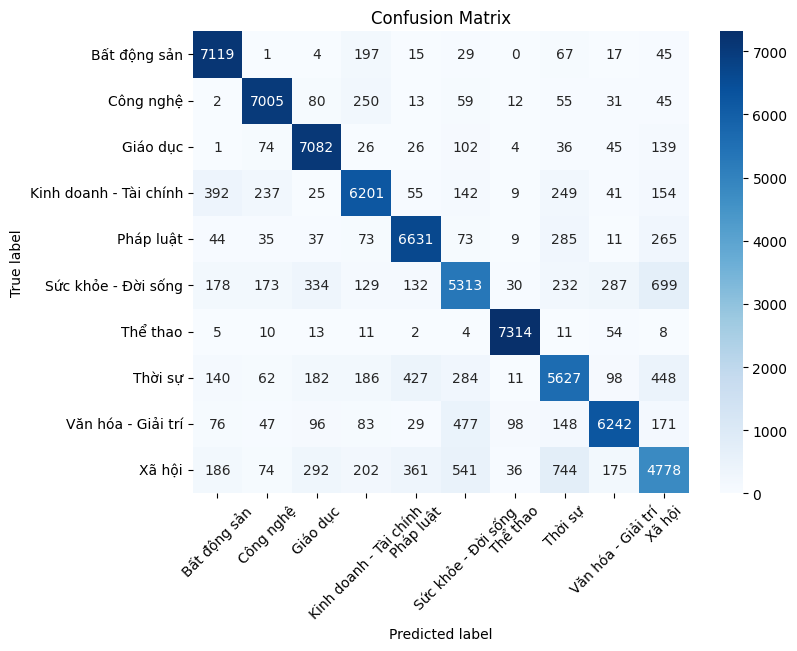

In [18]:
cm = confusion_matrix(y_test_labels, y_pred_labels)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45)  # nghiêng trục x
plt.yticks(rotation=0)
plt.title('Confusion Matrix')
plt.show()

# Gru Model

In [19]:
Gru_model = Sequential()
Gru_model.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=True
))

Gru_model.add(Bidirectional(GRU(256, return_sequences=False)))
Gru_model.add(LayerNormalization())
Gru_model.add(Dropout(0.3))
Gru_model.add(Dense(num_classes, activation='softmax',kernel_regularizer=l2(1e-4)))

loss_fn = CategoricalFocalCrossentropy(alpha=0.25, gamma=3.0, from_logits=False)
Gru_model.compile(
    loss= loss_fn,
    optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-4),
    metrics=['accuracy']
)

# Callback
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_BiGru.keras", monitor='val_loss', save_best_only=True),
    reduce_lr
]
# Train
Gru_model.fit(
    X_train_pad, 
    y_train,
    validation_data=(X_val_pad, y_val), 
    epochs = 30, 
    batch_size= 128, 
    callbacks=callbacks,
    shuffle=True
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 487s 177ms/step - accuracy: 0.6951 - loss: 0.1344 - val_accuracy: 0.8368 - val_loss: 0.0507 - learning_rate: 0.0010
Epoch 2/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 483s 177ms/step - accuracy: 0.8467 - loss: 0.0448 - val_accuracy: 0.8427 - val_loss: 0.0453 - learning_rate: 0.0010
Epoch 3/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 483s 177ms/step - accuracy: 0.8669 - loss: 0.0340 - val_accuracy: 0.8568 - val_loss: 0.0421 - learning_rate: 0.0010
Epoch 4/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 486s 178ms/step - accuracy: 0.8879 - loss: 0.0256 - val_accuracy: 0.8616 - val_loss: 0.0415 - learning_rate: 0.0010
Epoch 5/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 485s 178ms/step - accuracy: 0.9067 - loss: 0.0189 - val_accuracy: 0.8568 - val_loss: 0.0439 - learning_rate: 0.0010
Epoch 6/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9227 - loss: 0.0146
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 482s 177ms/st

In [20]:
# Load best model
best_Gru = tf.keras.models.load_model("best_BiGru.keras")

# Predict
y_pred_prob = best_Gru.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_int = np.argmax(y_test, axis=1)
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test_int)

# Báo cáo phân loại
report = classification_report(y_test_labels, y_pred_labels, digits=2)
print("===== Classification Report: BiGru=====")
print(report)

2338/2338 ━━━━━━━━━━━━━━━━━━━━ 81s 35ms/step
===== Classification Report: BiGru=====
                        precision    recall  f1-score   support

          Bất động sản       0.92      0.94      0.93      7494
             Công nghệ       0.93      0.94      0.94      7552
              Giáo dục       0.88      0.95      0.92      7535
Kinh doanh - Tài chính       0.86      0.86      0.86      7505
             Pháp luật       0.88      0.90      0.89      7463
   Sức khỏe - Đời sống       0.76      0.74      0.75      7507
              Thể thao       0.98      0.99      0.98      7432
               Thời sự       0.80      0.77      0.78      7465
    Văn hóa - Giải trí       0.89      0.87      0.88      7467
                Xã hội       0.72      0.68      0.70      7389

              accuracy                           0.86     74809
             macro avg       0.86      0.86      0.86     74809
          weighted avg       0.86      0.86      0.86     74809



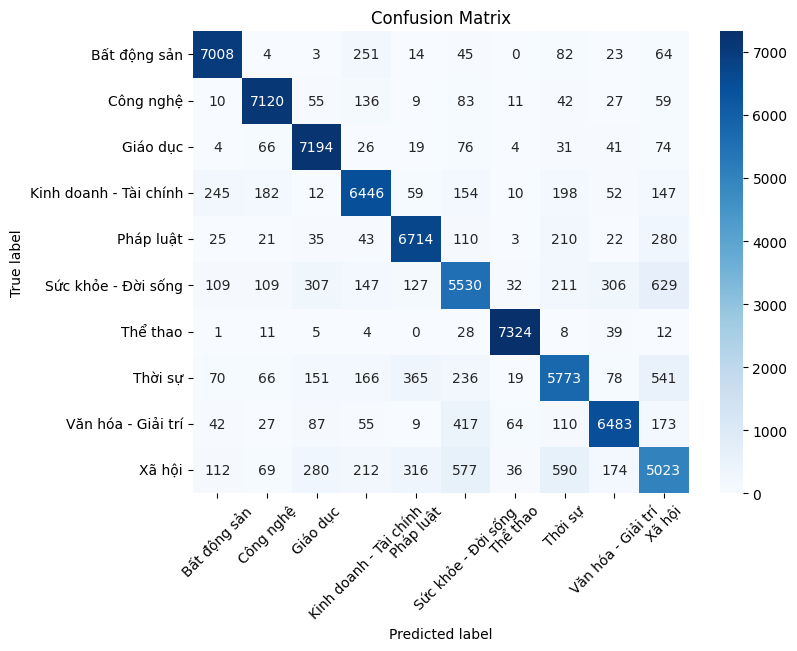

In [21]:
cm = confusion_matrix(y_test_labels, y_pred_labels)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45)  # nghiêng trục x
plt.yticks(rotation=0)
plt.title('Confusion Matrix')
plt.show()

In [22]:
bilstm_model = Sequential()
bilstm_model.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=True
))

# 2 BiLSTM layers với LayerNormalization
bilstm_model.add(Bidirectional(LSTM(256, dropout=0.2, return_sequences=False)))
bilstm_model.add(LayerNormalization())
# Dropout và Dense output
bilstm_model.add(Dropout(0.5))
bilstm_model.add(Dense(num_classes, activation='softmax',kernel_regularizer=l2(1e-4)))


# Compile
bilstm_model.compile(
    loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=0.25, gamma=3.0, from_logits=False),
    optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-4),
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_BiLSTM.keras", monitor='val_loss', save_best_only=True),
    reduce_lr
]

# Train
bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=30,
    batch_size=128,
    callbacks=callbacks,
    shuffle=True
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 618s 224ms/step - accuracy: 0.6767 - loss: 0.1467 - val_accuracy: 0.8042 - val_loss: 0.0680 - learning_rate: 0.0010
Epoch 2/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 612s 224ms/step - accuracy: 0.8074 - loss: 0.0628 - val_accuracy: 0.8280 - val_loss: 0.0525 - learning_rate: 0.0010
Epoch 3/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 612s 225ms/step - accuracy: 0.8430 - loss: 0.0440 - val_accuracy: 0.8417 - val_loss: 0.0459 - learning_rate: 0.0010
Epoch 4/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 613s 225ms/step - accuracy: 0.8623 - loss: 0.0341 - val_accuracy: 0.8507 - val_loss: 0.0441 - learning_rate: 0.0010
Epoch 5/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 612s 224ms/step - accuracy: 0.8785 - loss: 0.0274 - val_accuracy: 0.8543 - val_loss: 0.0455 - learning_rate: 0.0010
Epoch 6/30
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.8900 - loss: 0.0225
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 611s 224ms/st

In [23]:
# Load best model
best_bilstm = tf.keras.models.load_model("best_BiLSTM.keras")

# Predict
y_pred_prob = best_bilstm.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_int = np.argmax(y_test, axis=1)
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test_int)

# Báo cáo phân loại
report = classification_report(y_test_labels, y_pred_labels, digits=2)
print("===== Classification Report: BiLstm=====")
print(report)

2338/2338 ━━━━━━━━━━━━━━━━━━━━ 91s 39ms/step
===== Classification Report: BiLstm=====
                        precision    recall  f1-score   support

          Bất động sản       0.91      0.93      0.92      7494
             Công nghệ       0.90      0.95      0.93      7552
              Giáo dục       0.85      0.95      0.90      7535
Kinh doanh - Tài chính       0.86      0.83      0.84      7505
             Pháp luật       0.86      0.90      0.88      7463
   Sức khỏe - Đời sống       0.75      0.74      0.75      7507
              Thể thao       0.97      0.99      0.98      7432
               Thời sự       0.77      0.75      0.76      7465
    Văn hóa - Giải trí       0.92      0.81      0.86      7467
                Xã hội       0.71      0.65      0.68      7389

              accuracy                           0.85     74809
             macro avg       0.85      0.85      0.85     74809
          weighted avg       0.85      0.85      0.85     74809



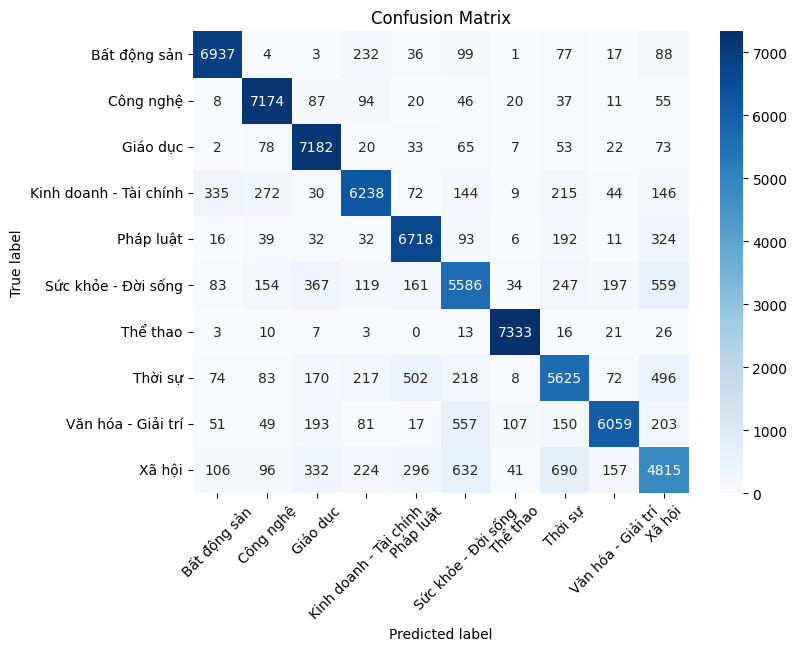

In [24]:
cm = confusion_matrix(y_test_labels, y_pred_labels)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45)  # nghiêng trục x
plt.yticks(rotation=0)
plt.title('Confusion Matrix')
plt.show()